# US-JEPA Encoder Evaluation

This notebook is separate from the pretraining notebook.
It loads:

    * checkpoints/config.json
    * checkpoints/encoder_best.pth

and then tries to answer the one question the pretraining notebook never
answered:

    Does the self-supervised encoder actually learn transferable,
    anatomically meaningful ultrasound representations or did it just
    find a low-loss shortcut?

Structure:

    Phase 1:Representation quality (no labels needed)
        1A. Embedding visualization: t-SNE, PCA, UMAP
        1B. Nearest-neighbour retrieval
        1C. Embedding statistics: variance, cosine similarity, covariance, norms
        1D. Pretrained encoder vs. a randomly-initialized encoder (the baseline
            that MUST be beaten for the pretraining to have done anything)

    Phase 2:Linear probing
        A ready-to-run frozen-encoder linear probe for whenever LI/MA
        annotations exist, PLUS an unsupervised proxy (k-means clustering +
        silhouette score) to use *today*, before labels exist.



In [ ]:
import os
import glob
import json
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import DataLoader

from PIL import Image
from einops import rearrange
from scipy import ndimage as ndi
from skimage.morphology import convex_hull_image

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print('umap-learn not installed — UMAP plot will be skipped. '
          'Install with: pip install umap-learn')

import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 1. Load config + pretrained encoder only


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

CHECKPOINT_DIR = '/content/drive/MyDrive/checkpoints'   # <-- adjust this path to match your Drive folder
EVAL_DIR = os.path.join(CHECKPOINT_DIR, 'eval')
os.makedirs(EVAL_DIR, exist_ok=True)

with open(os.path.join(CHECKPOINT_DIR, 'config.json')) as f:
    CFG = json.load(f)

print('Loaded config from checkpoints/config.json')
print(f"  img_size={CFG['img_size']}  patch_size={CFG['patch_size']}  "
      f"embed_dim={CFG['embed_dim']}  encoder_depth={CFG['encoder_depth']}")

Mounted at /content/drive
Loaded config from checkpoints/config.json
  img_size=256  patch_size=16  embed_dim=384  encoder_depth=8


## 2. Minimal model + data-loading code

Copied (not imported) from the pretraining notebook .

In [ ]:
#functional-state helpers
def move_model_dict_to_device(d, device):
    if isinstance(d, dict):
        for k, v in d.items():
            d[k] = move_model_dict_to_device(v, device)
        return d
    elif isinstance(d, list):
        return [move_model_dict_to_device(v, device) for v in d]
    elif isinstance(d, nn.Module):
        return d.to(device)
    elif isinstance(d, nn.Parameter):
        d.data = d.data.to(device)
        return d
    else:
        return d

def load_functional_state(saved, target):
    if isinstance(target, dict):
        for k in target:
            load_functional_state(saved[k], target[k])
    elif isinstance(target, list):
        for s, t in zip(saved, target):
            load_functional_state(s, t)
    elif isinstance(target, nn.Module):
        target.load_state_dict(saved)
    elif isinstance(target, nn.Parameter):
        target.data.copy_(saved.to(target.device))

def set_encoder_eval(encoder_dict):
    if isinstance(encoder_dict, dict):
        for v in encoder_dict.values():
            set_encoder_eval(v)
    elif isinstance(encoder_dict, list):
        for v in encoder_dict:
            set_encoder_eval(v)
    elif isinstance(encoder_dict, nn.Module):
        encoder_dict.eval()

# ViT encoder (must match the pretraining notebook exactly)
def init_patch_embed(in_channels=1, embed_dim=384, patch_size=16):
    return nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

def patch_embed_forward(x, proj_layer):
    x = proj_layer(x)
    return rearrange(x, 'b d h w -> b (h w) d')

def init_transformer_block(embed_dim, n_heads, mlp_ratio=4.0, dropout=0.0):
    hidden = int(embed_dim * mlp_ratio)
    return nn.ModuleDict({
        'norm1': nn.LayerNorm(embed_dim),
        'attn':  nn.MultiheadAttention(embed_dim, n_heads, dropout=dropout, batch_first=True),
        'norm2': nn.LayerNorm(embed_dim),
        'mlp':   nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, embed_dim),
            nn.Dropout(dropout),
        )
    })

def transformer_block_forward(x, layers):
    n = layers['norm1'](x)
    attn_out, _ = layers['attn'](n, n, n, need_weights=False)
    x = x + attn_out
    x = x + layers['mlp'](layers['norm2'](x))
    return x

def init_vit_encoder(img_size=224, patch_size=16, in_channels=1, embed_dim=384, depth=8, n_heads=6):
    patch_embed = init_patch_embed(in_channels, embed_dim, patch_size)
    grid_size = img_size // patch_size
    n_patches = grid_size ** 2

    cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
    pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
    blocks = [init_transformer_block(embed_dim, n_heads) for _ in range(depth)]
    norm = nn.LayerNorm(embed_dim)

    def _init_layer_weights(module):
        for m in module.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv2d):
                nn.init.trunc_normal_(m.weight, std=0.02)

    nn.init.trunc_normal_(cls_token, std=0.02)
    nn.init.trunc_normal_(pos_embed, std=0.02)
    _init_layer_weights(patch_embed)
    for block in blocks:
        for sub_layer in block.values():
            _init_layer_weights(sub_layer)

    return {
        'patch_embed': patch_embed, 'cls_token': cls_token, 'pos_embed': pos_embed,
        'blocks': blocks, 'norm': norm, 'grid_size': grid_size, 'n_patches': n_patches,
    }

def vit_encoder_forward(x, encoder_layers, context_mask=None):
    tokens = patch_embed_forward(x, encoder_layers['patch_embed'])
    B, N, D = tokens.shape
    cls = encoder_layers['cls_token'].expand(B, -1, -1)
    tokens = torch.cat([cls, tokens], dim=1)
    tokens = tokens + encoder_layers['pos_embed']
    if context_mask is not None:
        keep = torch.cat([
            torch.ones(B, 1, dtype=torch.bool, device=x.device), context_mask
        ], dim=1)
        tokens_list = [tokens[b][keep[b]] for b in range(B)]
        max_len = max(t.shape[0] for t in tokens_list)
        padded = torch.zeros(B, max_len, D, device=x.device, dtype=tokens.dtype)
        for b, t in enumerate(tokens_list):
            padded[b, :t.shape[0]] = t
        tokens = padded
    for block in encoder_layers['blocks']:
        tokens = transformer_block_forward(tokens, block)
    return encoder_layers['norm'](tokens)

def load_pretrained_encoder(cfg, weights_path, device):
    encoder = init_vit_encoder(
        img_size=cfg['img_size'], patch_size=cfg['patch_size'],
        in_channels=cfg['img_channels'], embed_dim=cfg['embed_dim'],
        depth=cfg['encoder_depth'], n_heads=cfg['encoder_heads'],
    )
    encoder = move_model_dict_to_device(encoder, device)
    load_functional_state(torch.load(weights_path, map_location=device), encoder)
    print(f'Pretrained encoder loaded from {weights_path}')
    return encoder

def build_random_encoder(cfg, device):
    """Same architecture, freshly initialized weights — the baseline the
    pretrained encoder must beat. This is the comparison the review flagged
    as missing."""
    encoder = init_vit_encoder(
        img_size=cfg['img_size'], patch_size=cfg['patch_size'],
        in_channels=cfg['img_channels'], embed_dim=cfg['embed_dim'],
        depth=cfg['encoder_depth'], n_heads=cfg['encoder_heads'],
    )
    encoder = move_model_dict_to_device(encoder, device)
    print('Randomly-initialized encoder built (no pretraining) — baseline for comparison.')
    return encoder

#data loading
def get_cubs_image_paths(data_dir):
    image_paths = sorted(
        glob.glob(os.path.join(data_dir, '*.tiff')) +
        glob.glob(os.path.join(data_dir, '*.tif'))
    )
    if not image_paths:
        raise FileNotFoundError(f'No TIFF images found in {data_dir!r}.')
    print(f'[CUBS] Found {len(image_paths)} images in {data_dir}')
    return image_paths

def get_eval_transforms(img_size):
    return T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize(mean=[0.5], std=[0.5]),
    ])

def load_cubs_item(path, transform=None):
    name = os.path.splitext(os.path.basename(path))[0]
    img = Image.open(path).convert('L')
    if transform:
        img = transform(img)
    return img, name

print('Model + data utilities ready.')

Model + data utilities ready.


## 3. Load both encoders

In [ ]:
encoder_ckpt_path = os.path.join(CHECKPOINT_DIR, 'encoder_best.pth')
pretrained_encoder = load_pretrained_encoder(CFG, encoder_ckpt_path, DEVICE)
set_encoder_eval(pretrained_encoder)

random_encoder = build_random_encoder(CFG, DEVICE)
set_encoder_eval(random_encoder)

ENCODERS = {
    'pretrained': {'context_encoder': pretrained_encoder},
    'random_init': {'context_encoder': random_encoder},
}

Pretrained encoder loaded from /content/drive/MyDrive/checkpoints/encoder_best.pth
Randomly-initialized encoder built (no pretraining) — baseline for comparison.


## 4. Extract embeddings for both encoders

In [ ]:
@torch.no_grad()
def extract_embeddings(paths, model_dict, cfg, device, max_images=500, batch_size=16):
    """Mean-pooled, L2-normalized patch embeddings (cls token excluded).
    Runs the *unmasked* encoder — this measures general representation
    quality, not the JEPA prediction task itself."""
    transform = get_eval_transforms(cfg['img_size'])
    paths = paths[:max_images]
    embeddings, names = [], []

    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i + batch_size]
        imgs = []
        for p in batch_paths:
            img, name = load_cubs_item(p, transform=transform)
            imgs.append(img)
            names.append(name)
        imgs = torch.stack(imgs).to(device)

        tokens = vit_encoder_forward(imgs, model_dict['context_encoder'], context_mask=None)
        patch_tokens = tokens[:, 1:]
        pooled = patch_tokens.mean(dim=1)
        pooled = F.normalize(pooled, dim=-1)
        embeddings.append(pooled.cpu())

    return torch.cat(embeddings, dim=0).numpy(), names

all_paths = get_cubs_image_paths(CFG['data_dir'])

MAX_IMAGES = 500
results = {}
for tag, model_dict in ENCODERS.items():
    emb, names = extract_embeddings(all_paths, model_dict, CFG, DEVICE, max_images=MAX_IMAGES)
    results[tag] = {'embeddings': emb, 'names': names}
    print(f'[{tag}] embeddings extracted: {emb.shape}')

pretrained_emb = results['pretrained']['embeddings']
pretrained_names = results['pretrained']['names']
random_emb = results['random_init']['embeddings']

[CUBS] Found 2177 images in /content/drive/MyDrive/IMAGES
[pretrained] embeddings extracted: (500, 384)
[random_init] embeddings extracted: (500, 384)


## Phase 1A: Embedding visualization: t-SNE, PCA, UMAP

One blob with no structure = the encoder is not separating anything.
Visible clusters / gradients = the encoder is responding to *something*
in the images (texture, anatomy, acquisition settings still to be
interpreted, but a necessary precondition for usefulness).

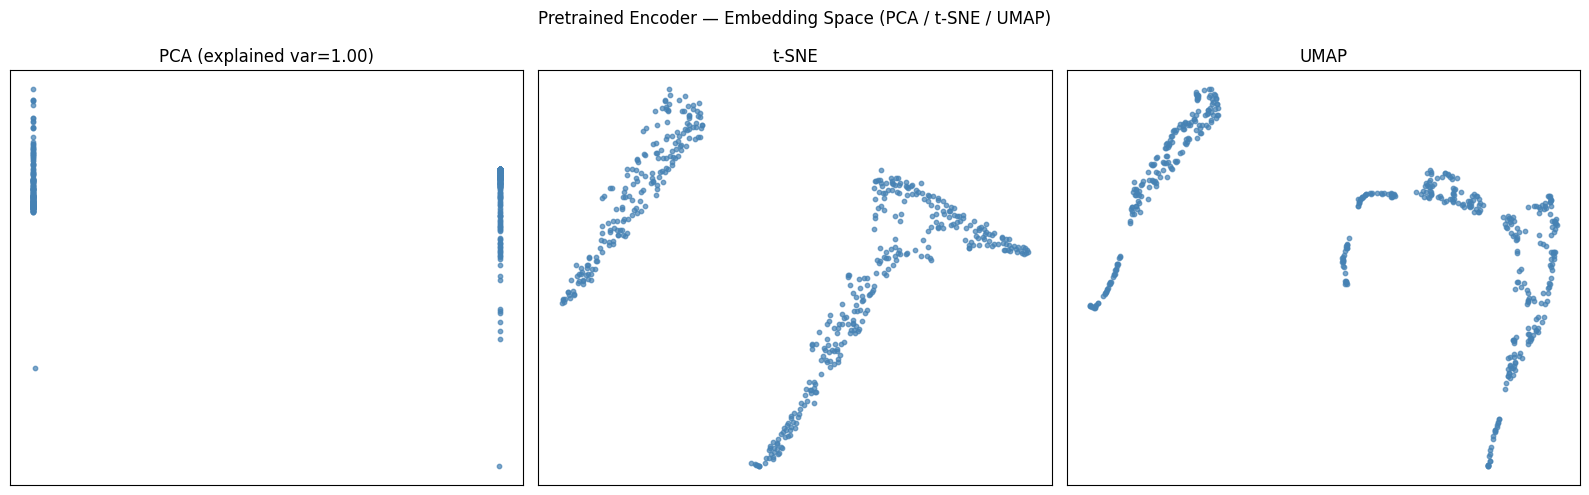

In [ ]:
def plot_2d(coords, title, fname, ax=None):
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(coords[:, 0], coords[:, 1], s=10, alpha=0.7, c='steelblue')
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    if own_fig:
        plt.tight_layout()
        plt.savefig(os.path.join(EVAL_DIR, fname), dpi=150)
        plt.show()

fig, axes = plt.subplots(1, 3 if UMAP_AVAILABLE else 2, figsize=(16, 5))

pca = PCA(n_components=2, random_state=SEED)
pca_2d = pca.fit_transform(pretrained_emb)
plot_2d(pca_2d, f'PCA (explained var={pca.explained_variance_ratio_.sum():.2f})', None, ax=axes[0])

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init='pca')
tsne_2d = tsne.fit_transform(pretrained_emb)
plot_2d(tsne_2d, 't-SNE', None, ax=axes[1])

if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_components=2, random_state=SEED)
    umap_2d = reducer.fit_transform(pretrained_emb)
    plot_2d(umap_2d, 'UMAP', None, ax=axes[2])

plt.suptitle('Pretrained Encoder — Embedding Space (PCA / t-SNE / UMAP)')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'embedding_projections.png'), dpi=150)
plt.show()

## Phase 1B: Nearest-neighbour retrieval

Classic SSL sanity check: take a query image, retrieve its 5 nearest
embeddings, and look at whether they're actually similar. This is a
qualitative check inspect the saved figures yourself.

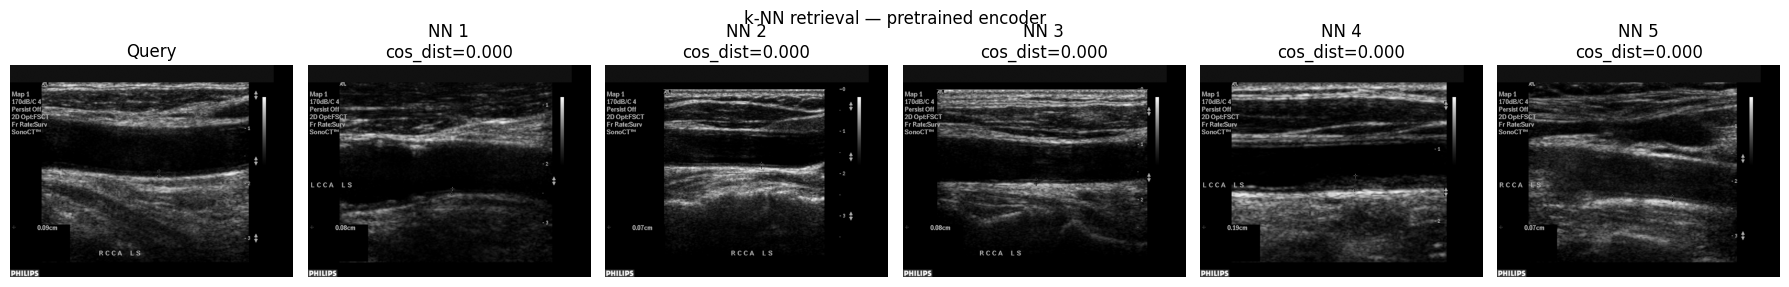

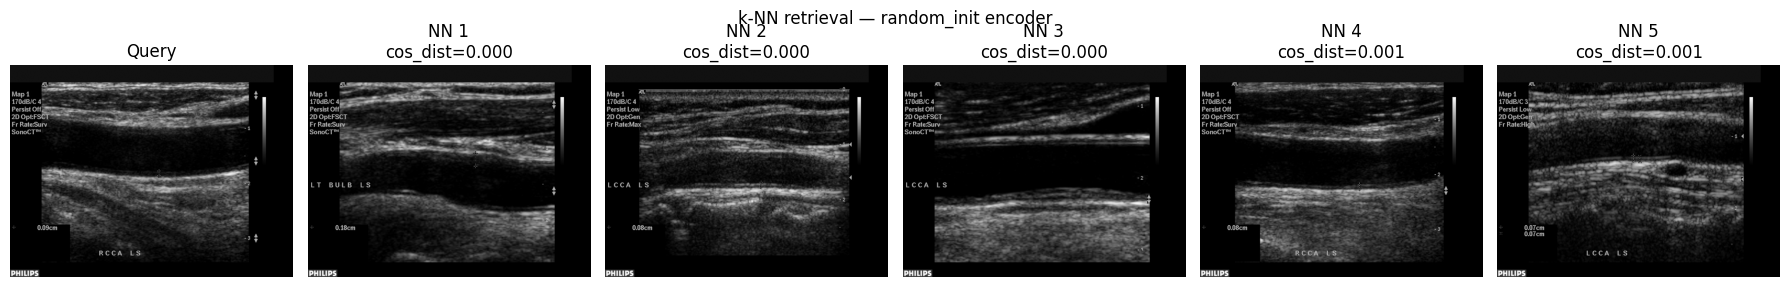

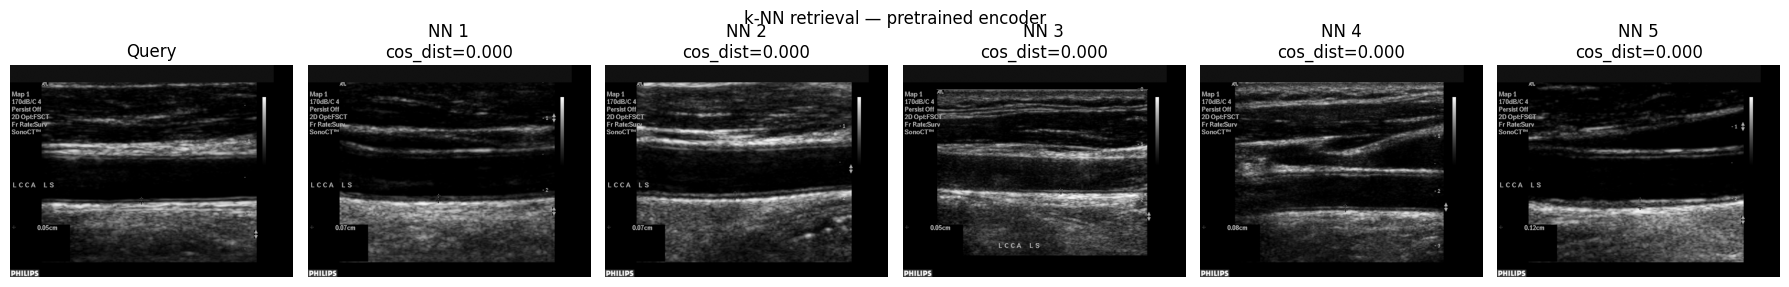

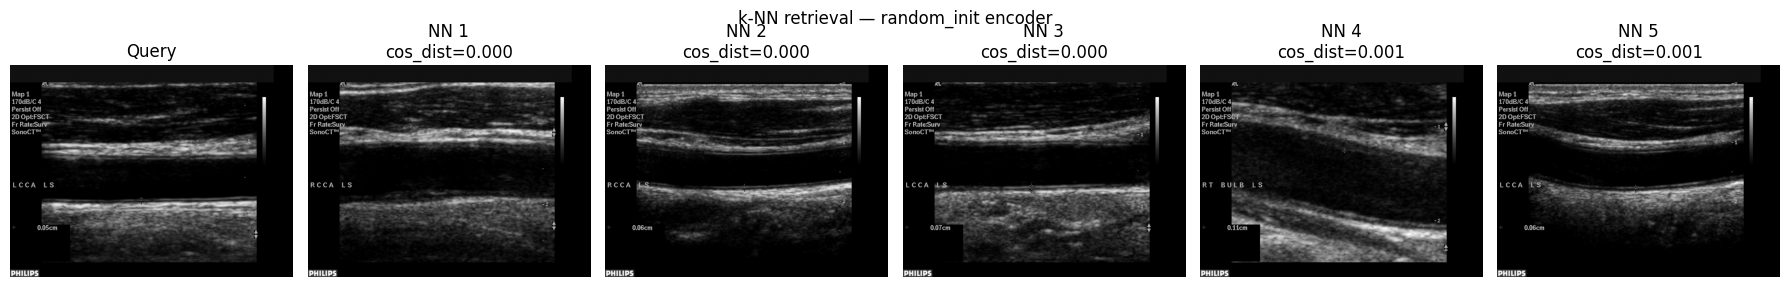

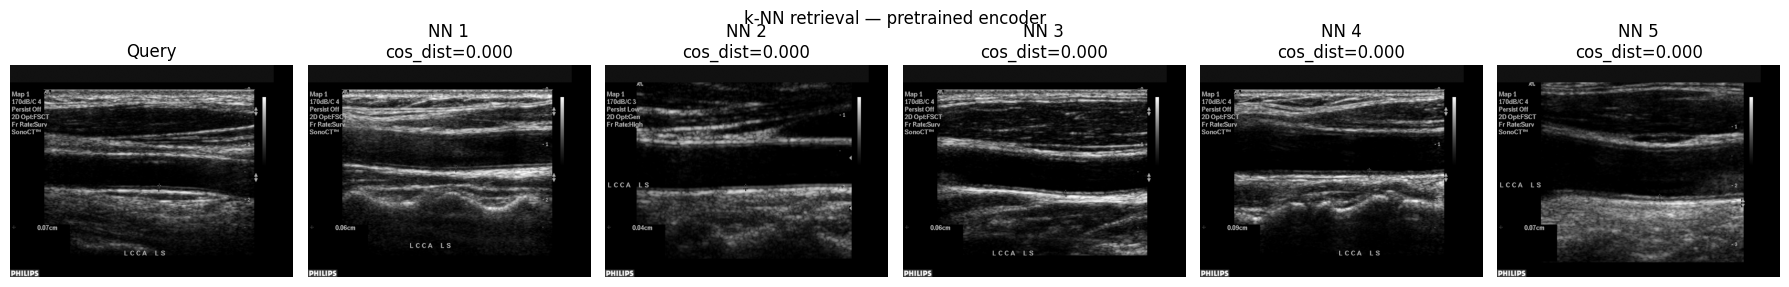

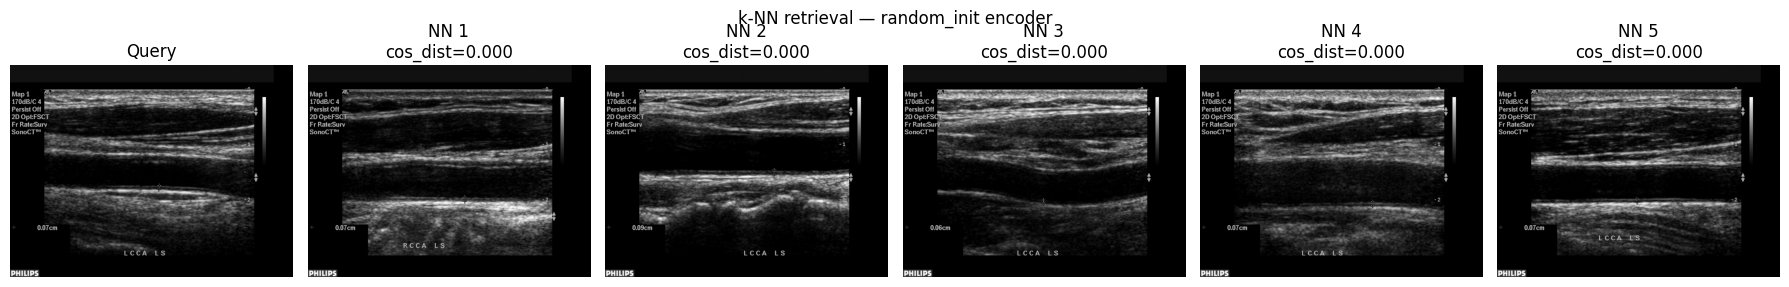

In [ ]:
def show_knn_retrieval(query_idx, embeddings, image_names, paths, k=5, tag='pretrained'):
    nn_model = NearestNeighbors(n_neighbors=k + 1, metric='cosine').fit(embeddings)
    dists, idxs = nn_model.kneighbors(embeddings[query_idx:query_idx + 1])
    idxs, dists = idxs[0][1:], dists[0][1:]

    path_by_name = {os.path.splitext(os.path.basename(p))[0]: p for p in paths}
    query_path = path_by_name.get(image_names[query_idx])

    fig, axes = plt.subplots(1, k + 1, figsize=(3 * (k + 1), 3))
    axes[0].imshow(Image.open(query_path).convert('L'), cmap='gray')
    axes[0].set_title('Query'); axes[0].axis('off')

    for j, (idx, d) in enumerate(zip(idxs, dists)):
        neighbor_path = path_by_name.get(image_names[idx])
        axes[j + 1].imshow(Image.open(neighbor_path).convert('L'), cmap='gray')
        axes[j + 1].set_title(f'NN {j+1}\ncos_dist={d:.3f}')
        axes[j + 1].axis('off')

    plt.suptitle(f'k-NN retrieval — {tag} encoder')
    plt.tight_layout()
    plt.savefig(os.path.join(EVAL_DIR, f'knn_{tag}_query{query_idx}.png'), dpi=150)
    plt.show()

rng = np.random.default_rng(SEED)
query_indices = rng.choice(len(pretrained_emb), size=3, replace=False)
for q in query_indices:
    show_knn_retrieval(int(q), pretrained_emb, pretrained_names, all_paths, k=5, tag='pretrained')
    show_knn_retrieval(int(q), random_emb, results['random_init']['names'], all_paths, k=5, tag='random_init')

## Phase 1C: Embedding statistics: variance, cosine similarity, covariance, norms

These are the quantitative signals the review specifically asked for,
computed for **both** encoders so they can be compared directly.


=== Embedding quality: pretrained vs. random-init ===
metric                           pretrained    random_init
----------------------------------------------------------
mean_per_dim_std                     0.0495         0.0022
min_per_dim_std                      0.0445         0.0008
mean_pairwise_cosine_sim             0.0558         0.9979
std_pairwise_cosine_sim              0.9983         0.0033
mean_abs_off_diag_cov                0.0025         0.0000
mean_norm                            1.0000         1.0000
std_norm                             0.0000         0.0000
effective_rank                       1.0015         5.0163


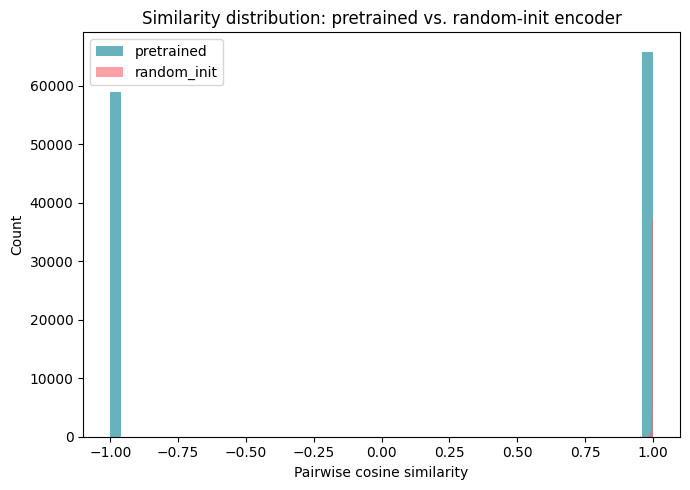


How to read this table:
  - If 'mean_pairwise_cosine_sim' for 'pretrained' is close to 1.0 while 'random_init' is much lower, the pretrained encoder may be *more* collapsed than a random network — that would be a red flag, not a success.
  - 'effective_rank' close to embed_dim means embeddings spread across most available directions; a value near 1 means near-total collapse.
  - These statistics alone still don't prove the embeddings are anatomically meaningful — that's what Phase 1A/1B and Phase 2 are for.


In [ ]:
def embedding_report(embeddings, tag):
    per_dim_std = embeddings.std(axis=0)
    norms = np.linalg.norm(embeddings, axis=1)

    sims = embeddings @ embeddings.T
    iu = np.triu_indices_from(sims, k=1)
    pairwise_sims = sims[iu]

    cov = np.cov(embeddings, rowvar=False)
    off_diag = cov[~np.eye(cov.shape[0], dtype=bool)]

    # Effective rank via normalized eigenvalue entropy (Roy & Vetterli)
    # a scalar proxy for "how many independent directions are actually used".
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.clip(eigvals, 1e-12, None)
    p = eigvals / eigvals.sum()
    entropy = -(p * np.log(p)).sum()
    effective_rank = float(np.exp(entropy))

    report = {
        'tag': tag,
        'mean_per_dim_std': float(per_dim_std.mean()),
        'min_per_dim_std': float(per_dim_std.min()),
        'mean_pairwise_cosine_sim': float(pairwise_sims.mean()),
        'std_pairwise_cosine_sim': float(pairwise_sims.std()),
        'mean_abs_off_diag_cov': float(np.abs(off_diag).mean()),
        'mean_norm': float(norms.mean()),
        'std_norm': float(norms.std()),
        'effective_rank': effective_rank,
        'embed_dim': embeddings.shape[1],
    }
    return report, pairwise_sims

pretrained_report, pretrained_sims = embedding_report(pretrained_emb, 'pretrained')
random_report, random_sims = embedding_report(random_emb, 'random_init')

print('\n=== Embedding quality: pretrained vs. random-init ===')
header = f"{'metric':<28}{'pretrained':>15}{'random_init':>15}"
print(header)
print('-' * len(header))
for key in ['mean_per_dim_std', 'min_per_dim_std', 'mean_pairwise_cosine_sim',
            'std_pairwise_cosine_sim', 'mean_abs_off_diag_cov', 'mean_norm',
            'std_norm', 'effective_rank']:
    print(f"{key:<28}{pretrained_report[key]:>15.4f}{random_report[key]:>15.4f}")

with open(os.path.join(EVAL_DIR, 'embedding_quality_report.json'), 'w') as f:
    json.dump({'pretrained': pretrained_report, 'random_init': random_report}, f, indent=2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(pretrained_sims, bins=50, alpha=0.6, label='pretrained', color='#028090')
ax.hist(random_sims, bins=50, alpha=0.6, label='random_init', color='#F96167')
ax.set_xlabel('Pairwise cosine similarity')
ax.set_ylabel('Count')
ax.set_title('Similarity distribution: pretrained vs. random-init encoder')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'similarity_comparison.png'), dpi=150)
plt.show()

print(
    "\nHow to read this table:\n"
    "  - If 'mean_pairwise_cosine_sim' for 'pretrained' is close to 1.0 while "
    "'random_init' is much lower, the pretrained encoder may be *more* collapsed "
    "than a random network — that would be a red flag, not a success.\n"
    "  - 'effective_rank' close to embed_dim means embeddings spread across most "
    "available directions; a value near 1 means near-total collapse.\n"
    "  - These statistics alone still don't prove the embeddings are anatomically "
    "meaningful — that's what Phase 1A/1B and Phase 2 are for."
)

*italicized text*## Phase 2: Linear probing

### 2A. Unsupervised proxy (usable *today*, no annotations required)

We don't have LI/MA labels yet, so as an interim signal we cluster the
embeddings with k-means and check whether the clusters are well-separated
(silhouette score). This is **not** a substitute for a real linear probe
it's a placeholder that gives an early, weak signal about whether the
representation has any exploitable structure at all.

In [ ]:
def unsupervised_cluster_probe(embeddings, tag, k_values=(2, 3, 4, 5, 8)):
    scores = {}
    for k in k_values:
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        labels = km.fit_predict(embeddings)
        score = silhouette_score(embeddings, labels)
        scores[k] = score
    best_k = max(scores, key=scores.get)
    print(f"[{tag}] silhouette scores by k: "
          + ', '.join(f'k={k}:{s:.3f}' for k, s in scores.items())
          + f'  (best: k={best_k})')
    return scores

print('\n=== Unsupervised cluster-separation proxy (silhouette score) ===')
pretrained_cluster_scores = unsupervised_cluster_probe(pretrained_emb, 'pretrained')
random_cluster_scores = unsupervised_cluster_probe(random_emb, 'random_init')


=== Unsupervised cluster-separation proxy (silhouette score) ===
[pretrained] silhouette scores by k: k=2:0.995, k=3:0.870, k=4:0.843, k=5:0.732, k=8:0.692  (best: k=2)
[random_init] silhouette scores by k: k=2:0.290, k=3:0.258, k=4:0.232, k=5:0.223, k=8:0.164  (best: k=2)


## Summary

Everything above is saved under `checkpoints/eval/`:

| File | What it answers |
|---|---|
| `embedding_projections.png` | Does the embedding space have structure at all? |
| `knn_pretrained_query*.png` / `knn_random_init_query*.png` | Do nearest neighbours look anatomically similar — and is that better than random init? |
| `embedding_quality_report.json` | Variance, cosine similarity, covariance, norms, effective rank — pretrained vs. random |
| `similarity_comparison.png` | Is the pretrained encoder more or less collapsed than random init? |


This notebook still does **not** answer the final question — does the
representation improve segmentation — because that requires annotated
LI/MA data. Phase 2B and Phase 3 are fully wired up and waiting for it.